# Origins of replication pre-analysis

From the raw MNase:
- Compute the total occupancy, origin occupancy (small fragments), and non origin occupancy (mostly nucleosomal).
- Compute the peak position of the small origin occupancy location.
- Plot the distribution of the total occupancies and determine a threshold to remove low coverage origins
- Plot the distribution of the proportion of small fragment reads to determine a threshold in which we do not identify an origin footprint.
- Create a column that labels the origins as having called footprints in our dataset.
- Save the constructed dataframe.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [536]:
from pipeline.precompute_origin_analysis import OriginFootprintAnalysis

window = 3000
origin_analysis = OriginFootprintAnalysis(window_size=window)

In [537]:
# Generate all the summary data at once (this may take some time)
small_fragments_data, composite_data = \
    origin_analysis.generate_summary_histogram_data(debug=False)

Generating summary histogram data for all timepoints and replicates...
Processing replicate 1...
  Processing chromosome 1 (21 origins) - 00:00:00.001
  Processing chromosome 2 (61 origins) - 00:00:08.117
  Processing chromosome 3 (31 origins) - 00:00:39.742
  Processing chromosome 4 (88 origins) - 00:00:51.345
  Processing chromosome 5 (33 origins) - 00:01:44.297
  Processing chromosome 6 (22 origins) - 00:02:01.081
  Processing chromosome 7 (63 origins) - 00:02:09.345
  Processing chromosome 8 (42 origins) - 00:02:45.217
  Processing chromosome 9 (38 origins) - 00:03:03.893
  Processing chromosome 10 (43 origins) - 00:03:18.770
  Processing chromosome 11 (42 origins) - 00:03:40.589
  Processing chromosome 12 (68 origins) - 00:04:00.571
  Processing chromosome 13 (56 origins) - 00:04:49.990
  Processing chromosome 14 (51 origins) - 00:05:19.181
  Processing chromosome 15 (67 origins) - 00:05:43.252
  Processing chromosome 16 (72 origins) - 00:06:21.188
Processing replicate 2...
  Proc

In [538]:
origin_analysis.composite_data[1][10].mean()

0.9845114298587474

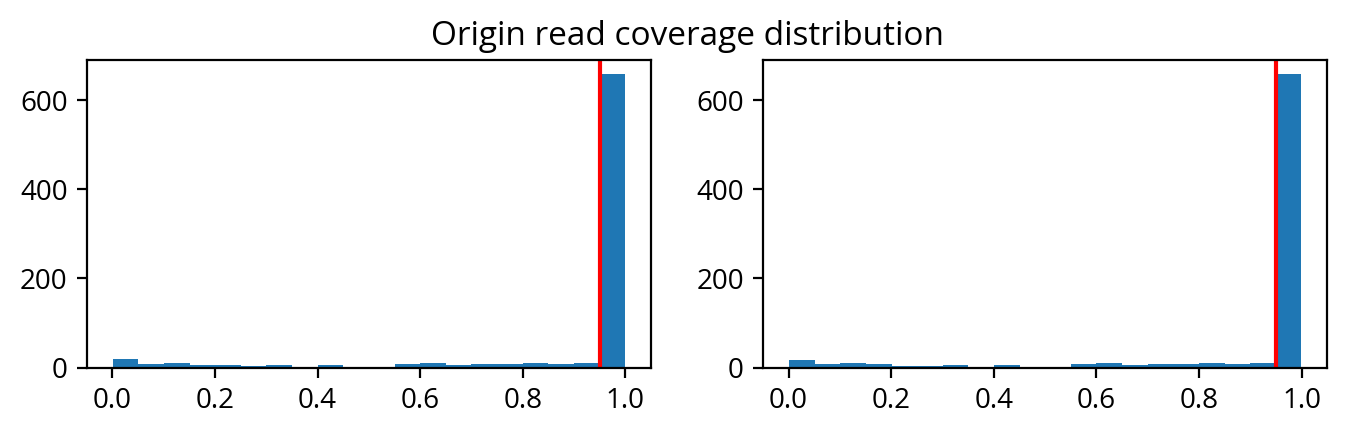

In [539]:
origin_analysis.plot_origin_read_coverage()

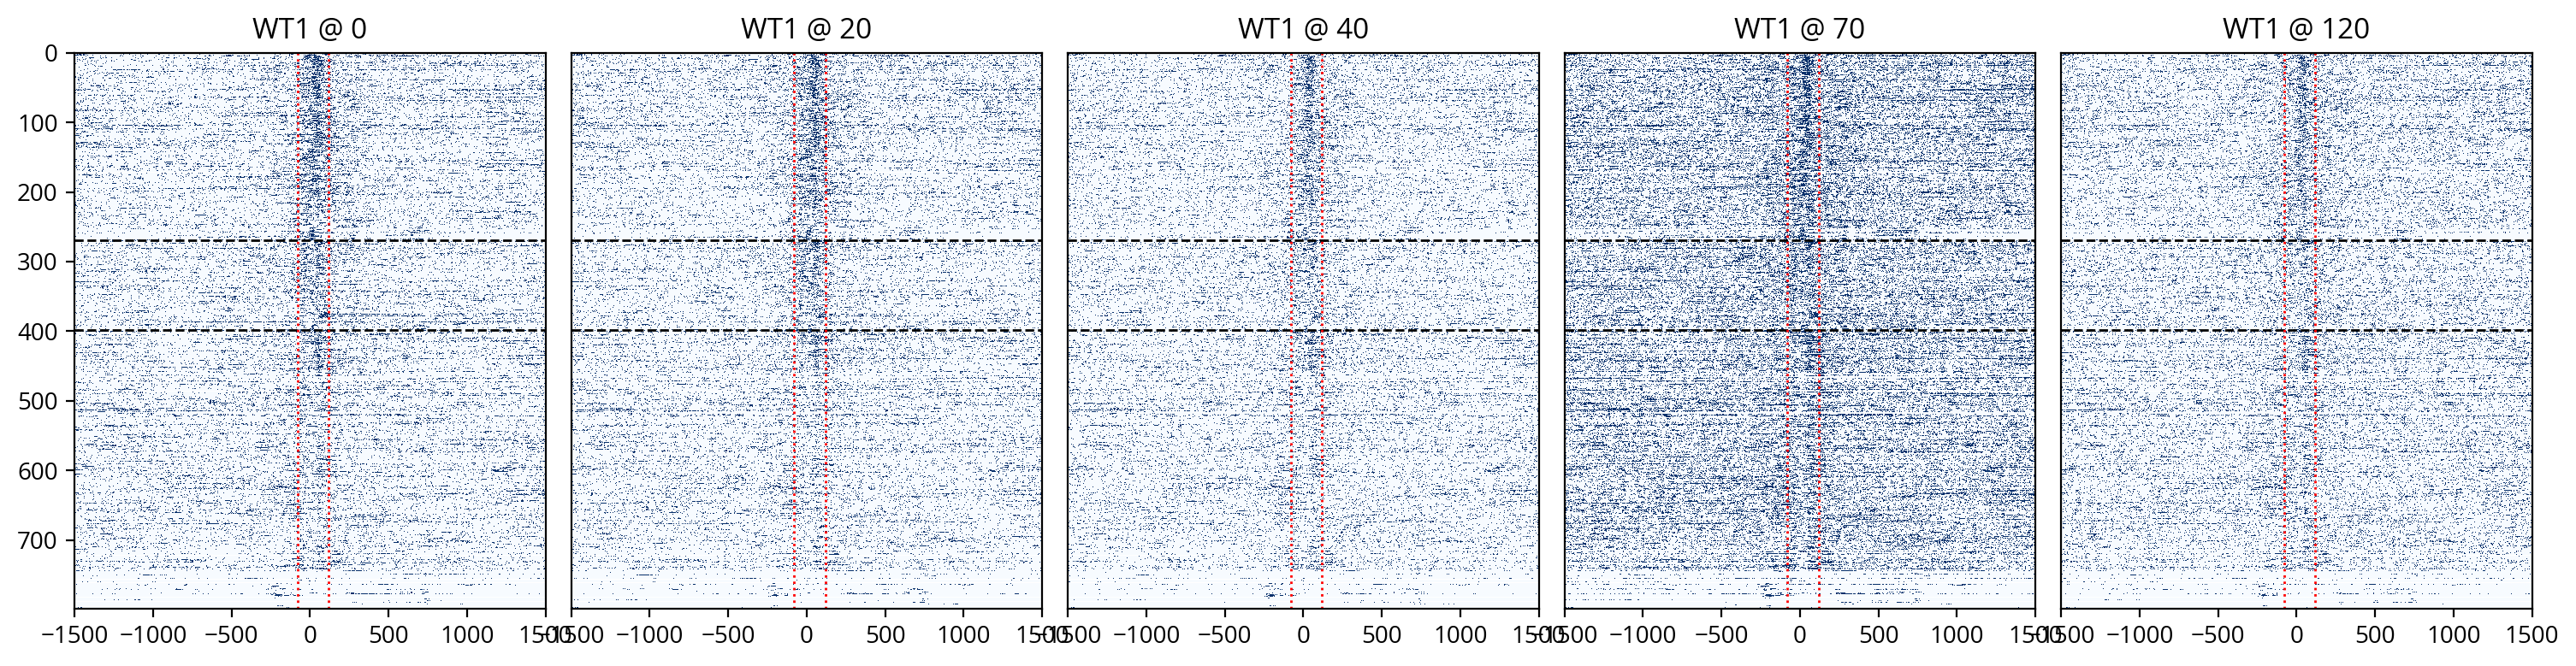

In [621]:
fig = origin_analysis.plot_timecourse_heatmaps(1, [0, 20, 40, 70, 120], sorted_origins)

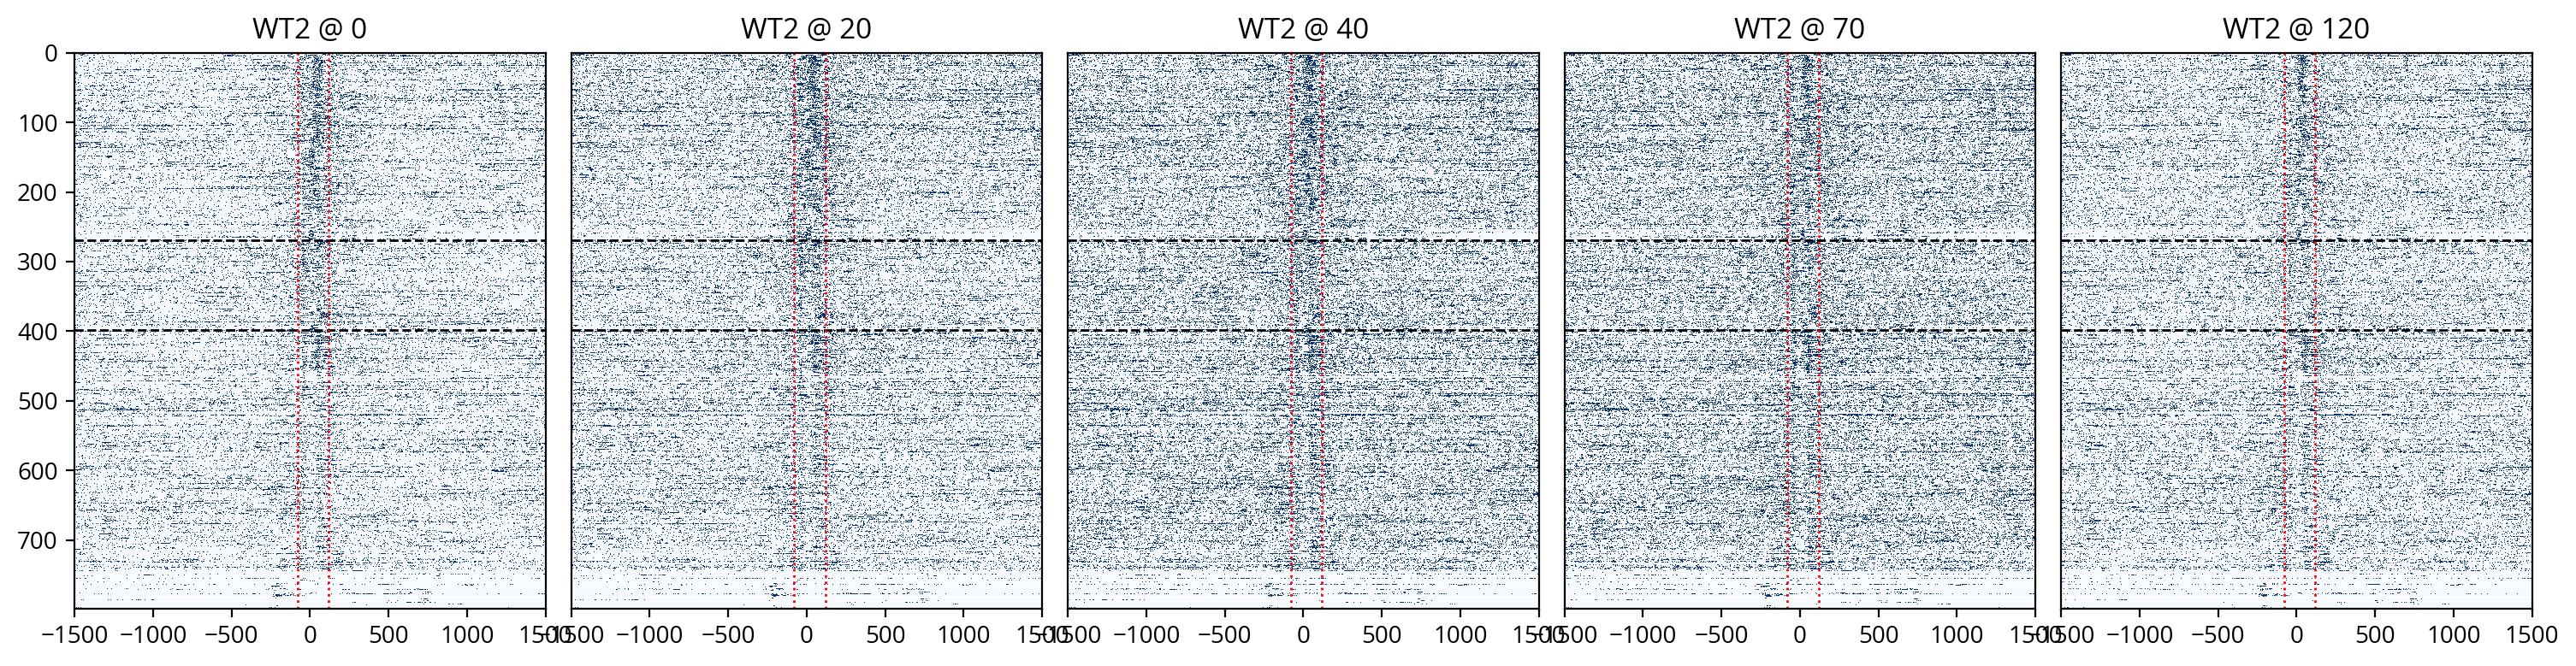

In [622]:
fig = origin_analysis.plot_timecourse_heatmaps(2, [0, 20, 40, 70, 120], sorted_origins)

In [628]:
def retrieve_footprints_array(origin_analysis, rep, sorted_origins,
                             footprint_coordinates=(-80, 120)):
    
    dat = origin_analysis.small_fragments_data[rep]
    
    # First create the empty array (as you did)
    n = len(dat)
    timepoints = list(dat.keys())
    num_origins = len(sorted_origins)
    width = len(dat[0]['oridb_1'])
    small_arr = np.zeros((n, num_origins, width))
    
    midpoint = width//2
    selection_span = midpoint+footprint_coordinates[0], midpoint+footprint_coordinates[1]    

    # Now populate the array with values
    for i in range(n):
        timepoint = timepoints[i]
        for j, origin_key in enumerate(sorted_origins.index):
            if origin_key in dat[timepoint].keys():
                small_arr[i, j] = dat[timepoint][origin_key]

    footprint_arr = small_arr[:, :, selection_span[0]:selection_span[1]]
                
    return timepoints, small_arr, footprint_arr

In [602]:
eff_key = 'derived_origin_efficiency_from_mcguffee_et_al_2013'
sorted_origins = origin_analysis.origins.sort_values(['footprint_class',
    eff_key], ascending=[True, False])

In [629]:
rep1_tps, rep1_small_arr, footprint1_arr = retrieve_footprints_array(origin_analysis, 1, sorted_origins)
rep2_tps, rep2_small_arr, footprint2_arr = retrieve_footprints_array(origin_analysis, 2, sorted_origins)


In [636]:
rep1_small_arr.shape

(16, 798, 3000)

Text(0.5, 1.0, 'Replicate 2')

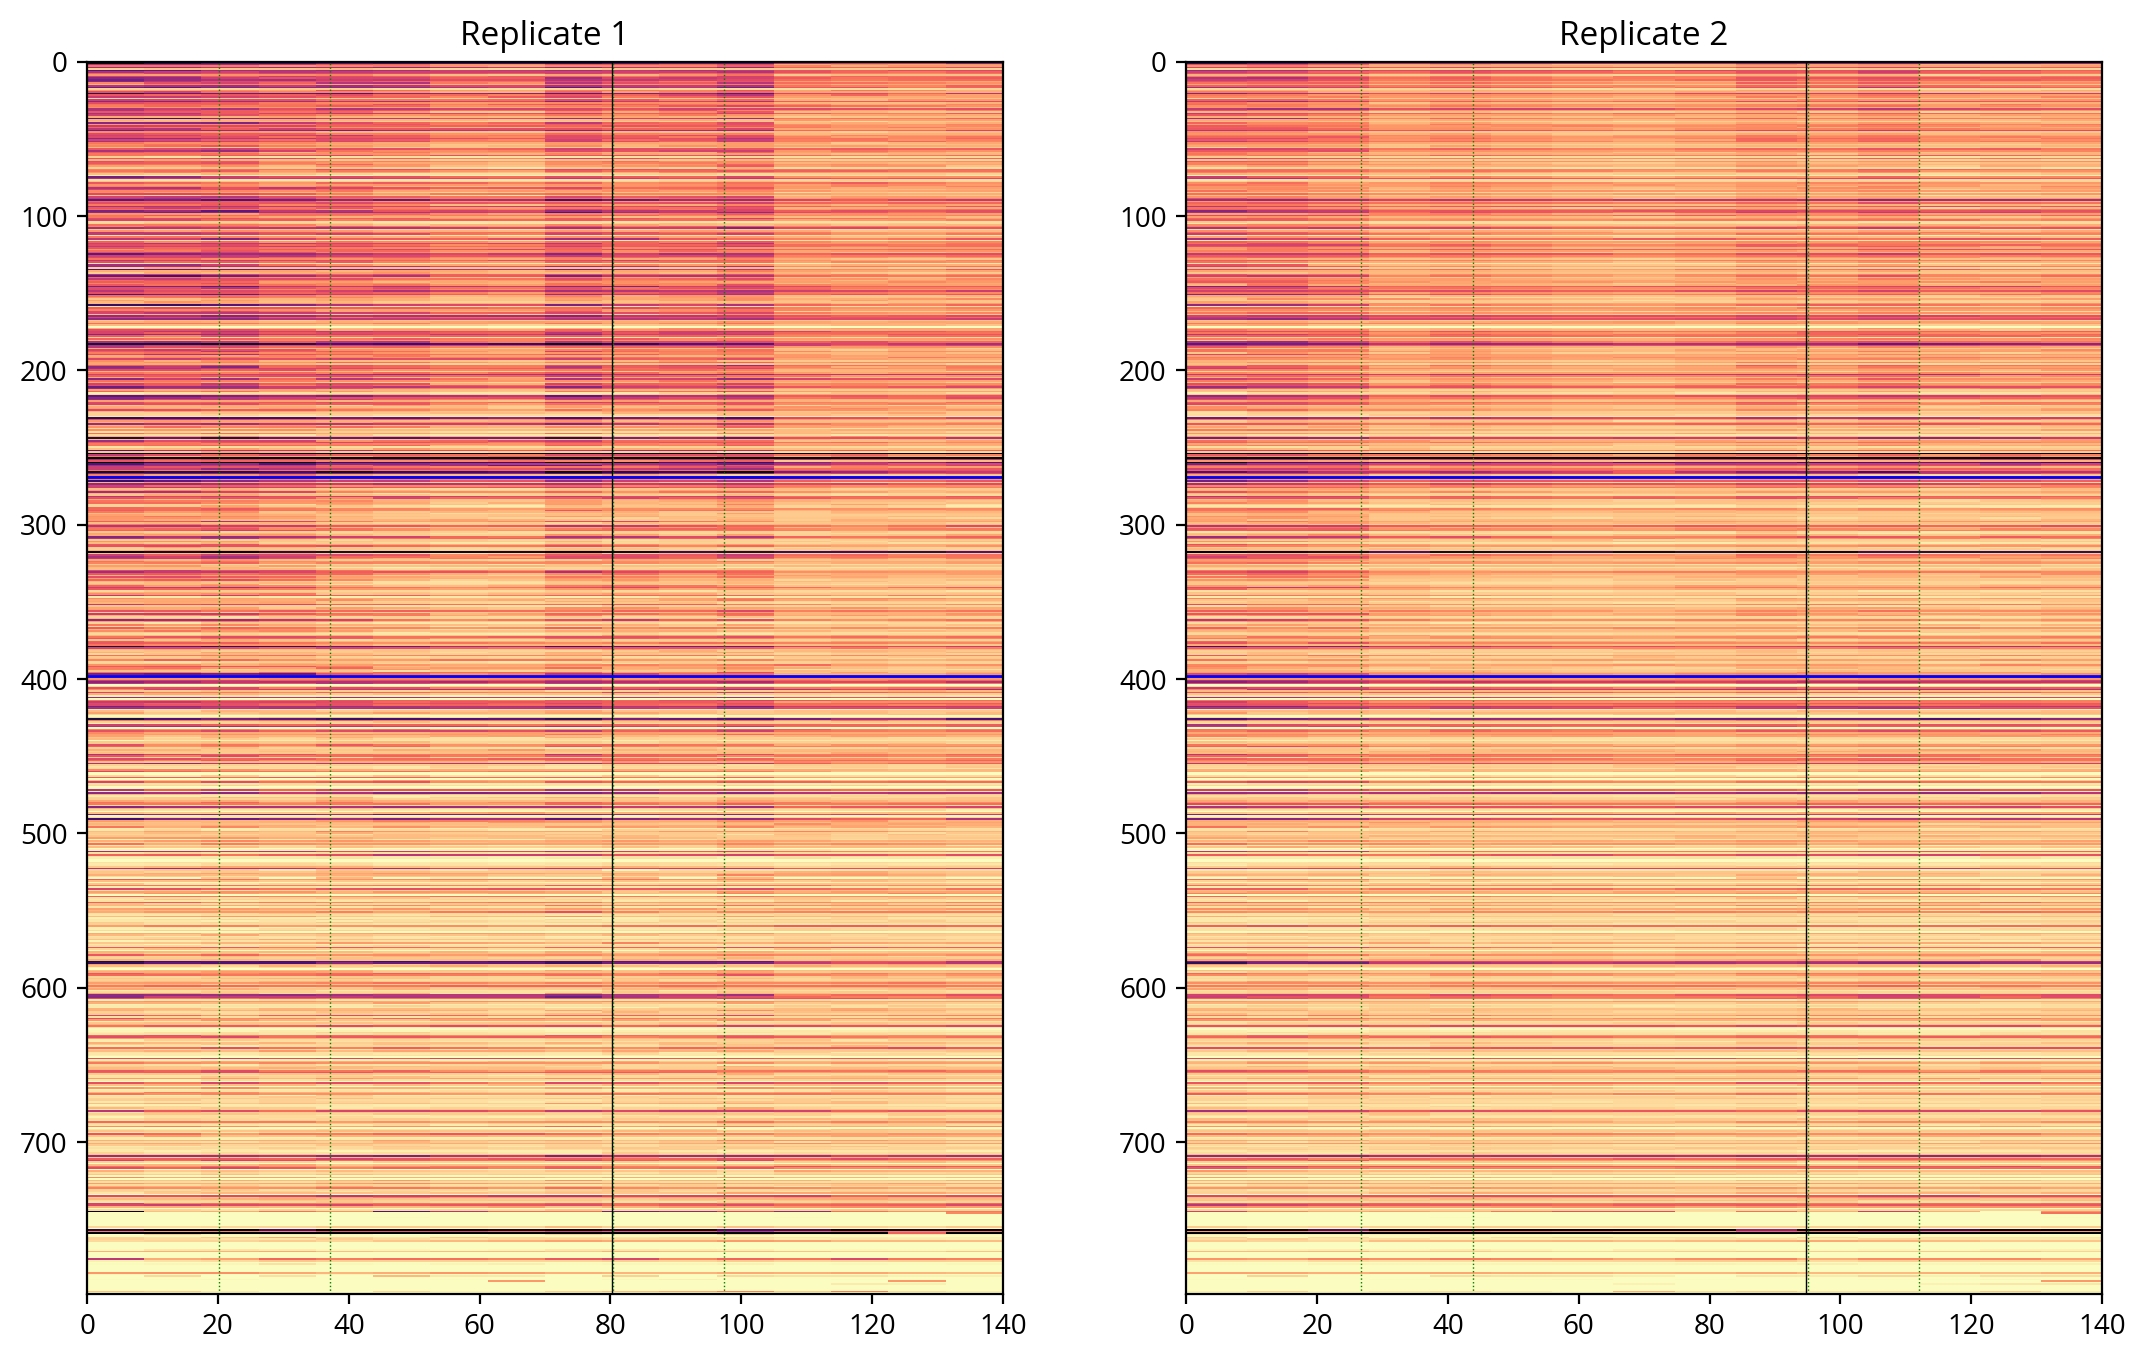

In [672]:

n = len(sorted_origins)

def plot_im_small_occs_tc(footprint_data, small_dat_arr, config, alpha, tps):
    config.modify_alpha(alpha)
    plot_raw_timepoints(config, s_color='green')
    footprint_normalized = footprint_data.mean(2).T / (small_dat_arr.mean(2).T + 1e-5)
    plt.imshow(footprint_normalized, aspect='auto', origin='lower',
              extent=[0, tps[-1], 0, n], cmap='magma_r', vmax=10,
              interpolation='none')
    num_footprint_g1_g2 = sum(sorted_origins.footprint_class == 'g1_and_g2_footprint')
    num_footprint_g1 = sum(sorted_origins.footprint_class == 'g1_only_footprint')
    if num_footprint_g1_g2 > 0:
        plt.axhline(num_footprint_g1_g2, c='blue', lw=1, ls='solid')
        plt.axhline(num_footprint_g1_g2+num_footprint_g1, c='blue', lw=1, ls='solid')
    plt.ylim(n, 0)

config1, config2 = load_default_chrom_configs()

plt.figure(figsize=(13, 8))
plt.subplot(1, 2, 1)
plot_im_small_occs_tc(footprint1_arr, rep1_small_arr, config2, 0, config2.timepoints)
plt.title("Replicate 1")

# config2.params_dic.update({'lambda': 60})
plt.subplot(1, 2, 2)

rep2_50_impute = rep2_small_arr.copy()
rep2_50_impute[5] = (rep2_50_impute[4]+rep2_50_impute[6])/2. 

foot2_50_impute = footprint2_arr.copy()
foot2_50_impute[5] = (foot2_50_impute[4]+foot2_50_impute[6])/2. 

plot_im_small_occs_tc(foot2_50_impute, rep2_50_impute, config1, 
    0, config2.timepoints)

plt.title("Replicate 2")

In [586]:
config1, config2 = load_default_chrom_configs()
config1.modify_alpha(0)
config2.modify_alpha(0)

Text(0.5, 1.1, 'Origin footprint occupancy in wild-type')

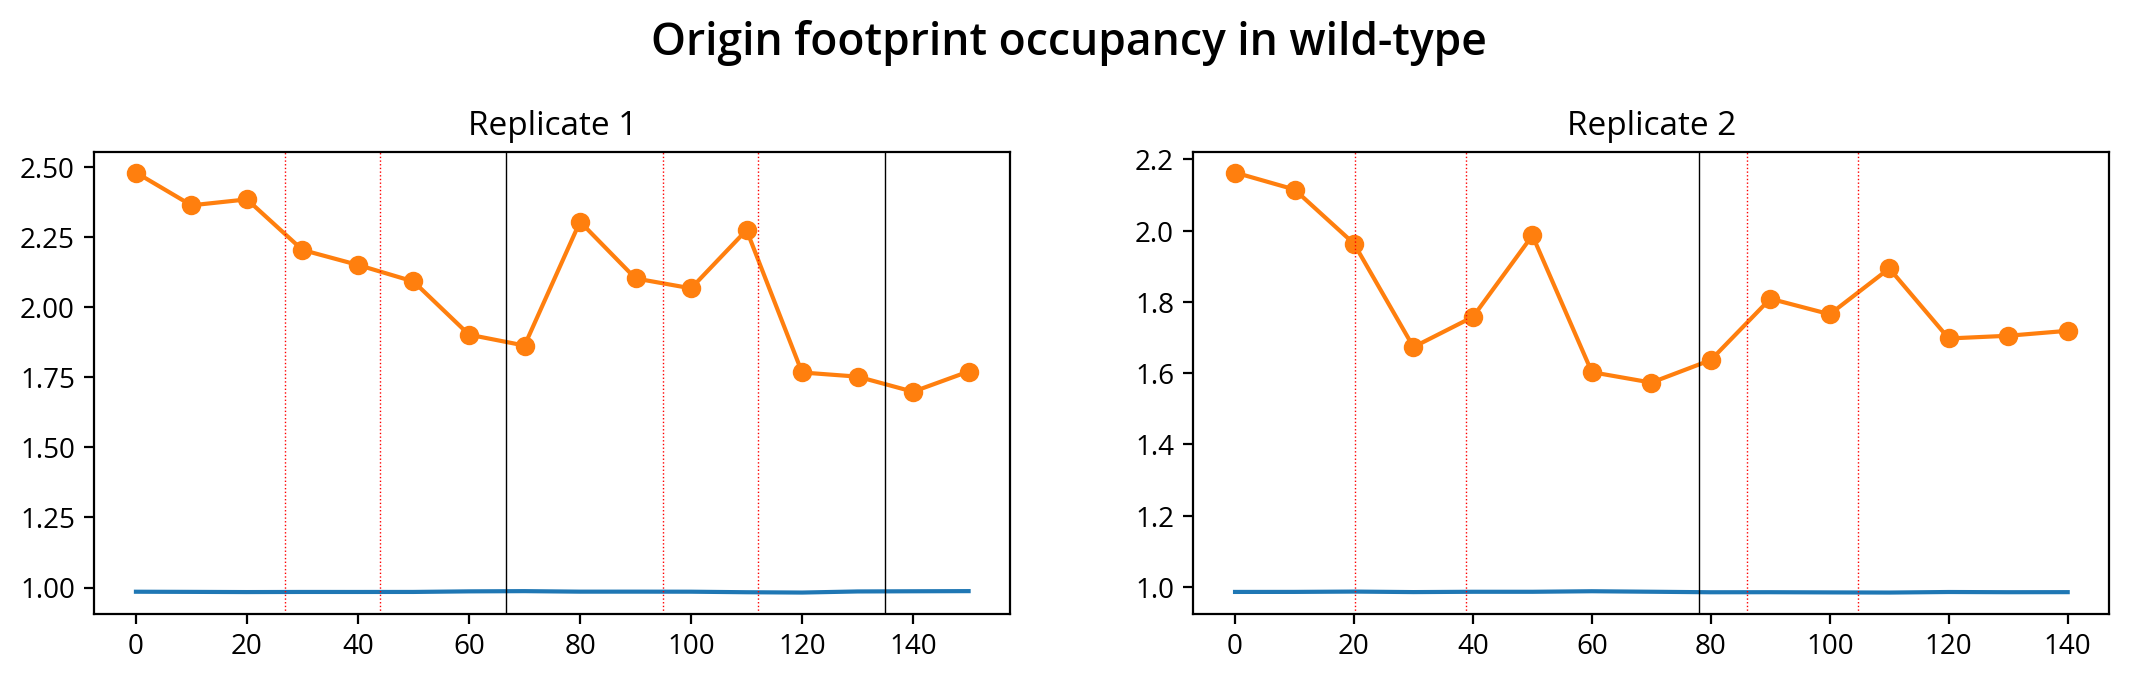

In [650]:
plt.figure(figsize=(13, 3))
plt.subplot(1, 2, 1)

plt.plot(rep1_timepoints, rep1_totals)
plt.plot(rep1_timepoints, rep1_small_means.mean(0), 'o-')
plot_raw_timepoints(config1)
plt.title("Replicate 1")

plt.subplot(1, 2, 2)
plt.plot(rep2_timepoints, rep2_totals)
plt.plot(rep2_timepoints, rep2_small_means.mean(0), 'o-')
plot_raw_timepoints(config2)
plt.title("Replicate 2")
plt.suptitle("Origin footprint occupancy in wild-type", fontsize=16, fontweight='demi', y=1.1)


In [546]:
def retrieve_total_sums_composite(origin_analysis, repl,
                                 fragment_lengths=(0,251)):

    data = origin_analysis.composite_data
    timepoints = list(data[repl].keys())
    total_sums = np.ones((len(timepoints)))

    for i, timepoint in enumerate(timepoints):
        total_sums[i] = data[repl][timepoint][
            fragment_lengths[0]:fragment_lengths[1], :].mean()
        
    return total_sums


In [550]:
from src.helpers import plot_raw_timepoints

In [548]:
config1, config2 = load_default_chrom_configs()
#config1.modify_alpha(45)
#config2.modify_alpha(30)

rep1_totals = retrieve_total_sums_composite(origin_analysis, 1)
rep2_totals = retrieve_total_sums_composite(origin_analysis, 2)

rep1_small_counts = retrieve_total_sums_composite(origin_analysis, 1, 
    fragment_lengths=(0, 120))
rep2_small_counts = retrieve_total_sums_composite(origin_analysis, 2,
    fragment_lengths=(0, 120))

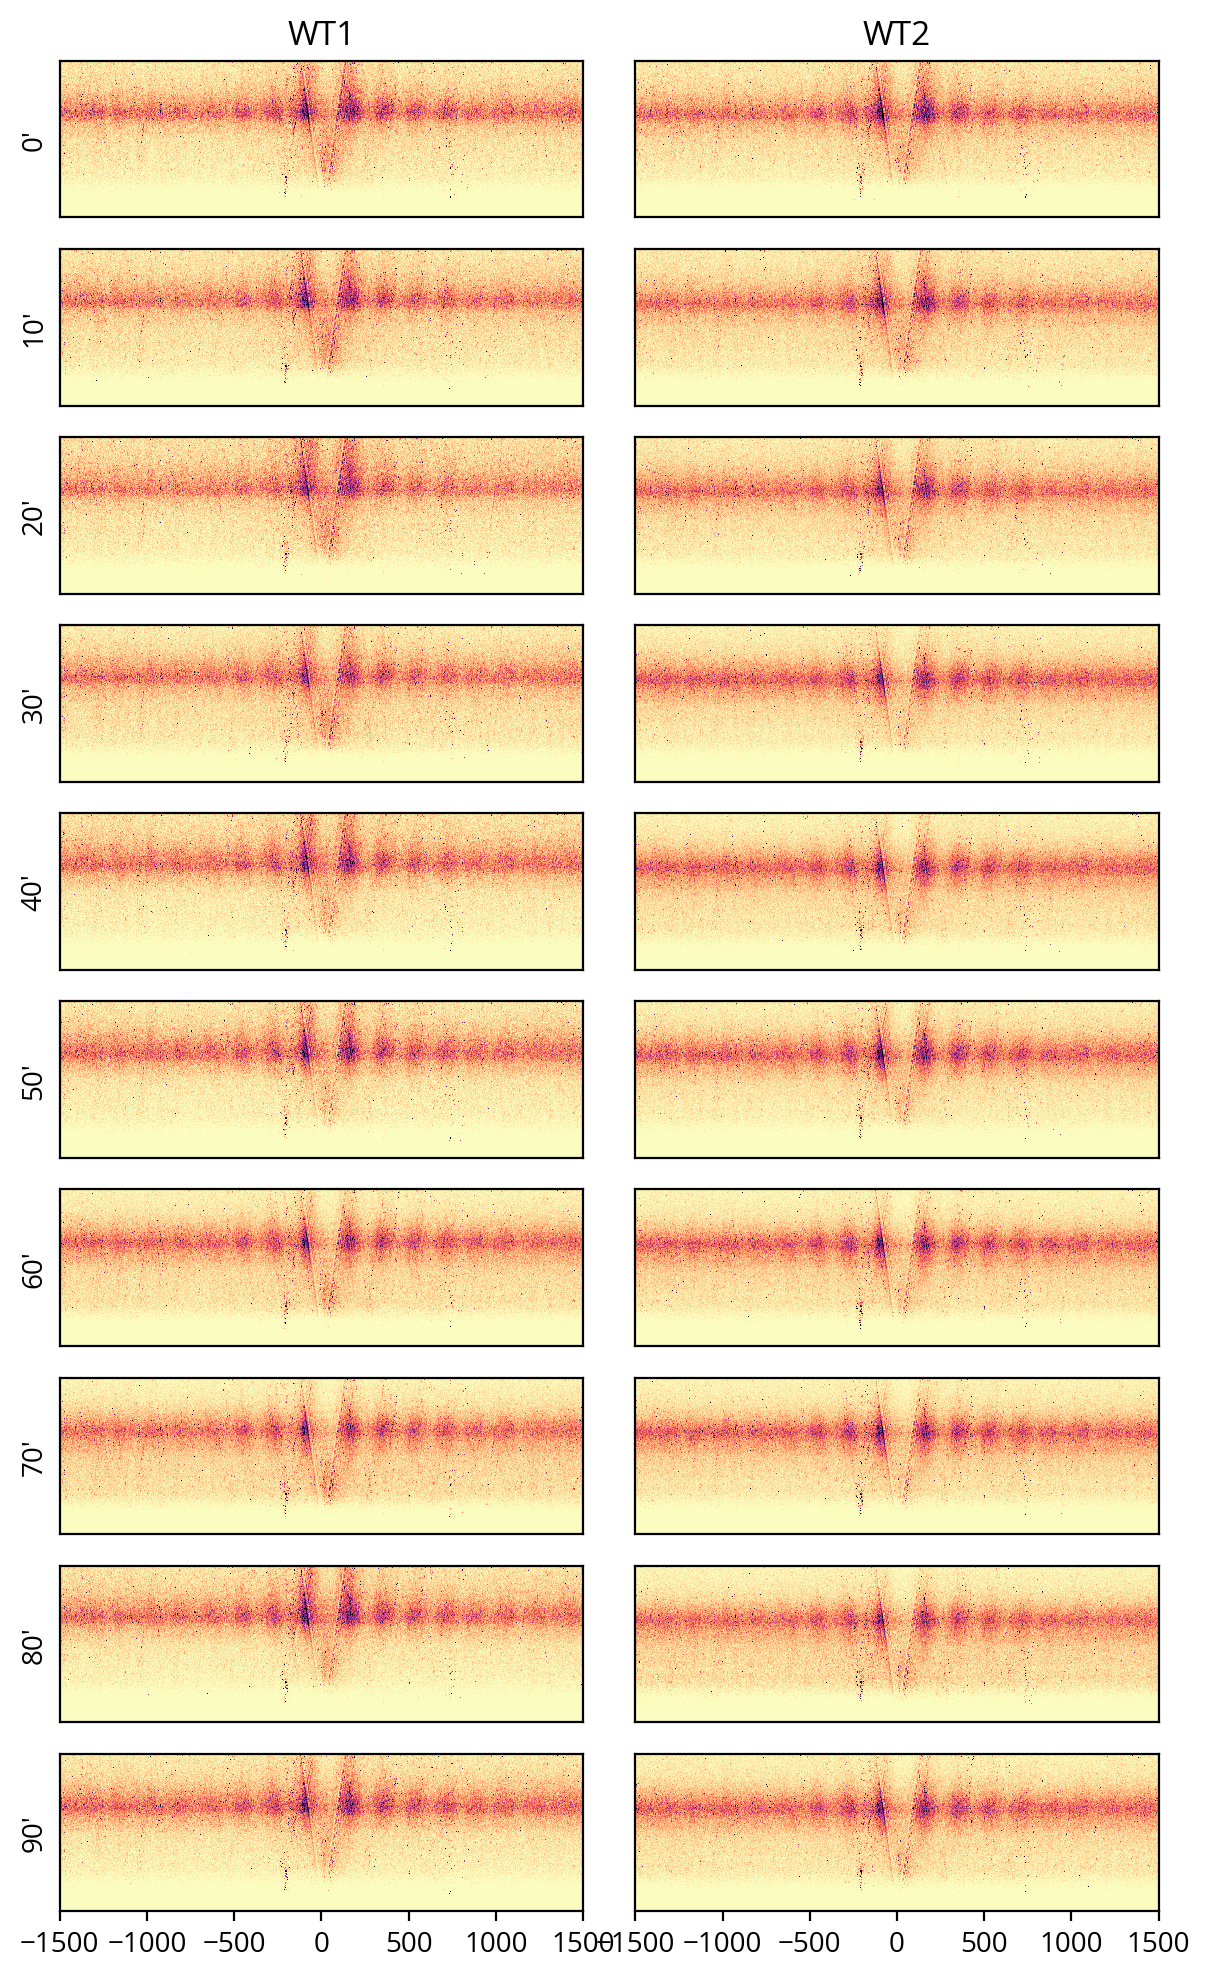

In [552]:
fig = origin_analysis.plot_composite_histograms([1, 2], 
    [0, 10, 20, 30, 40, 50, 60, 70, 80, 90], max_value=10)
